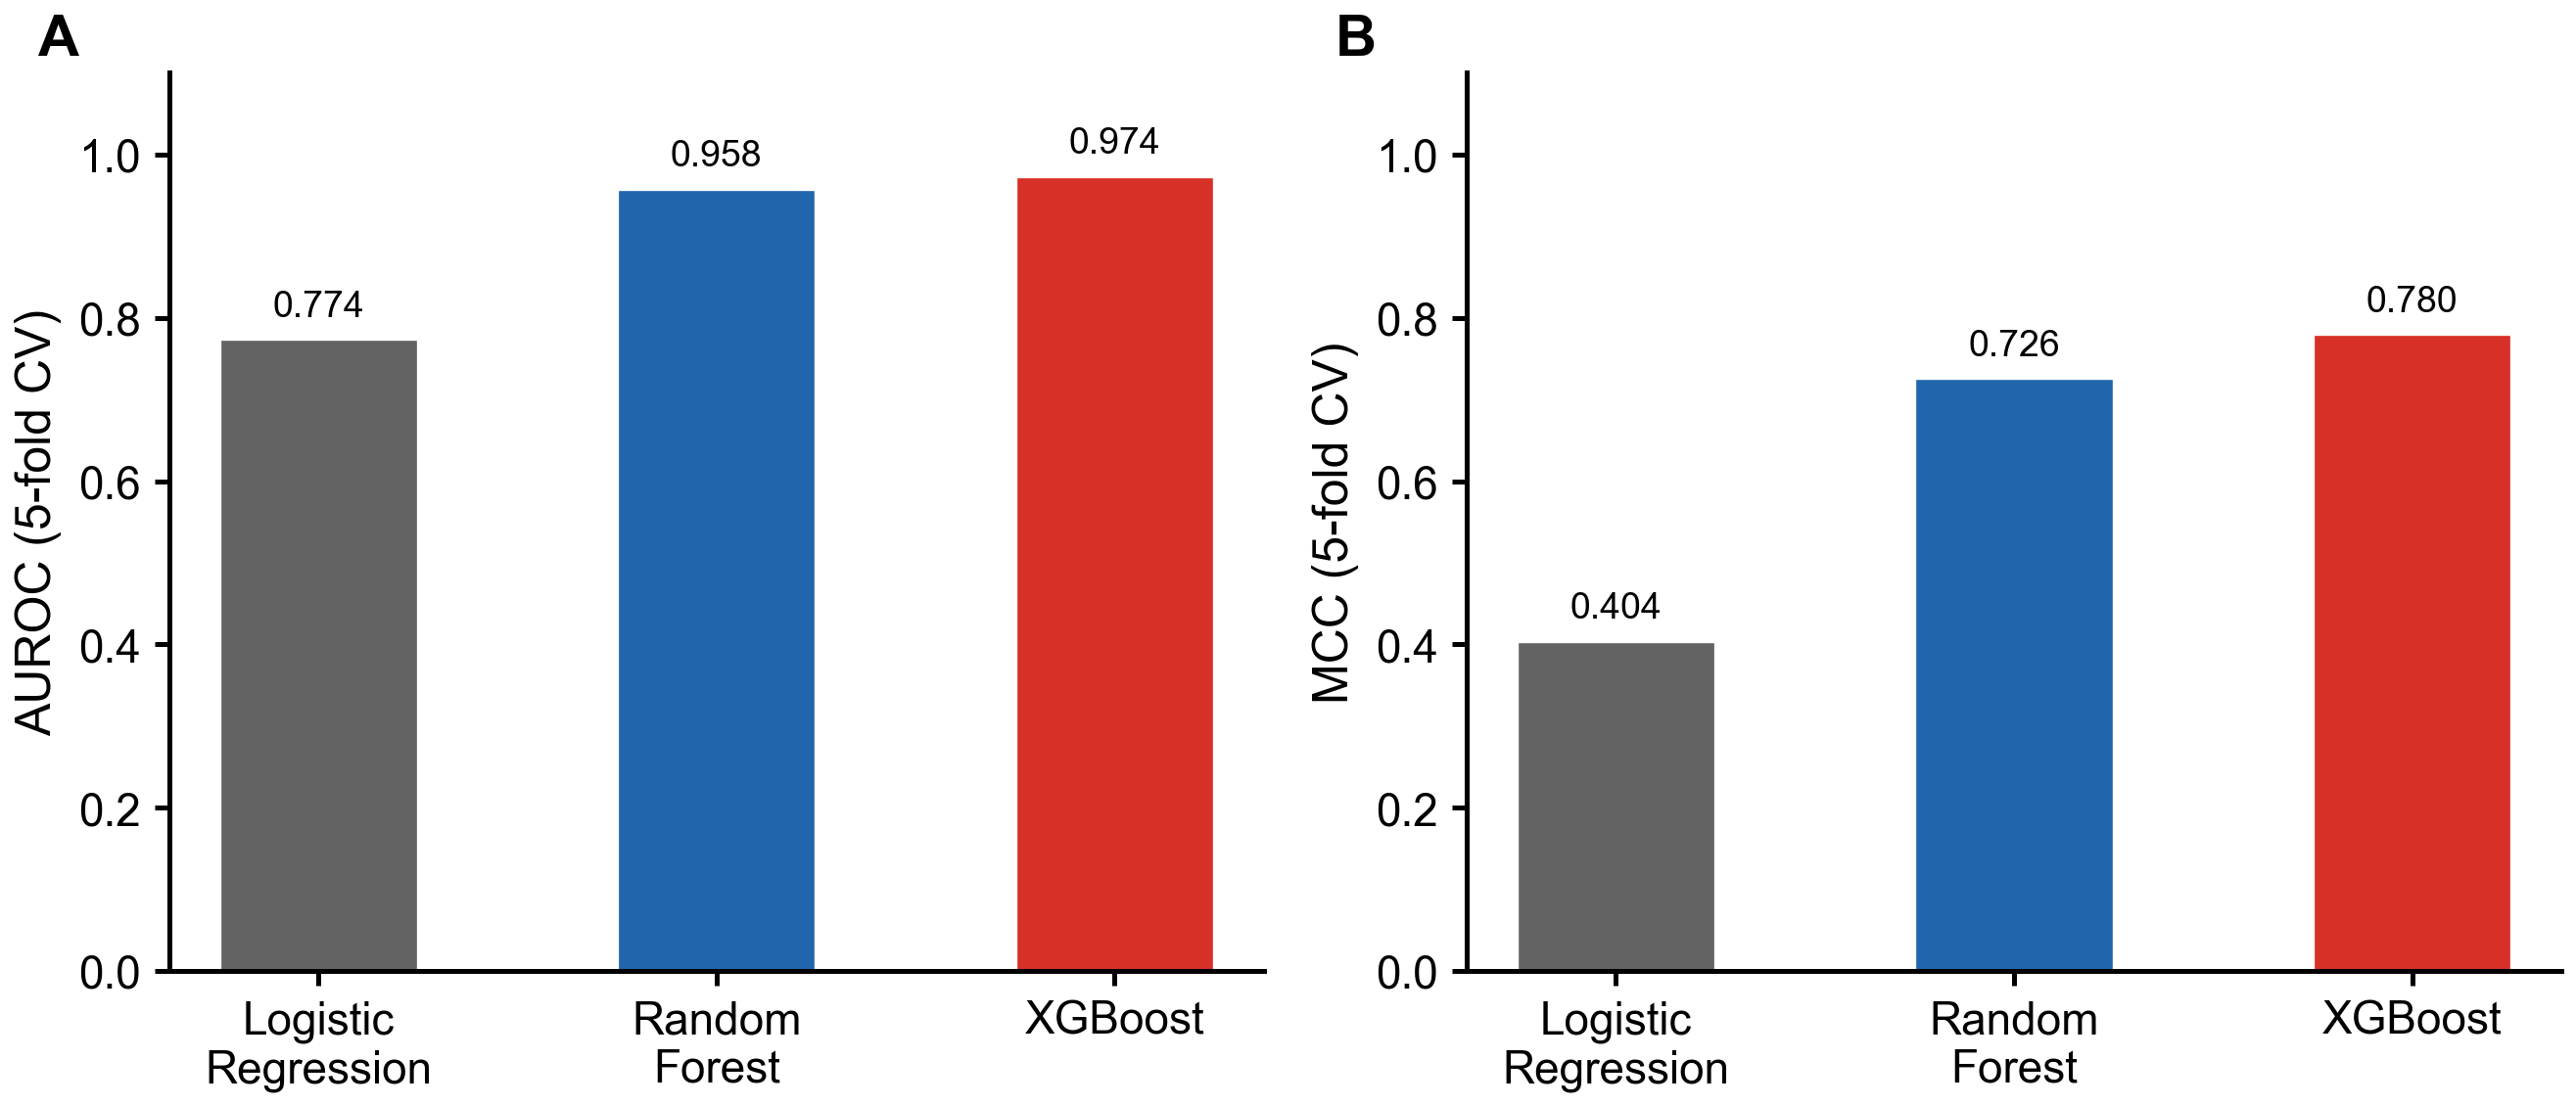

Figure 1 saved.


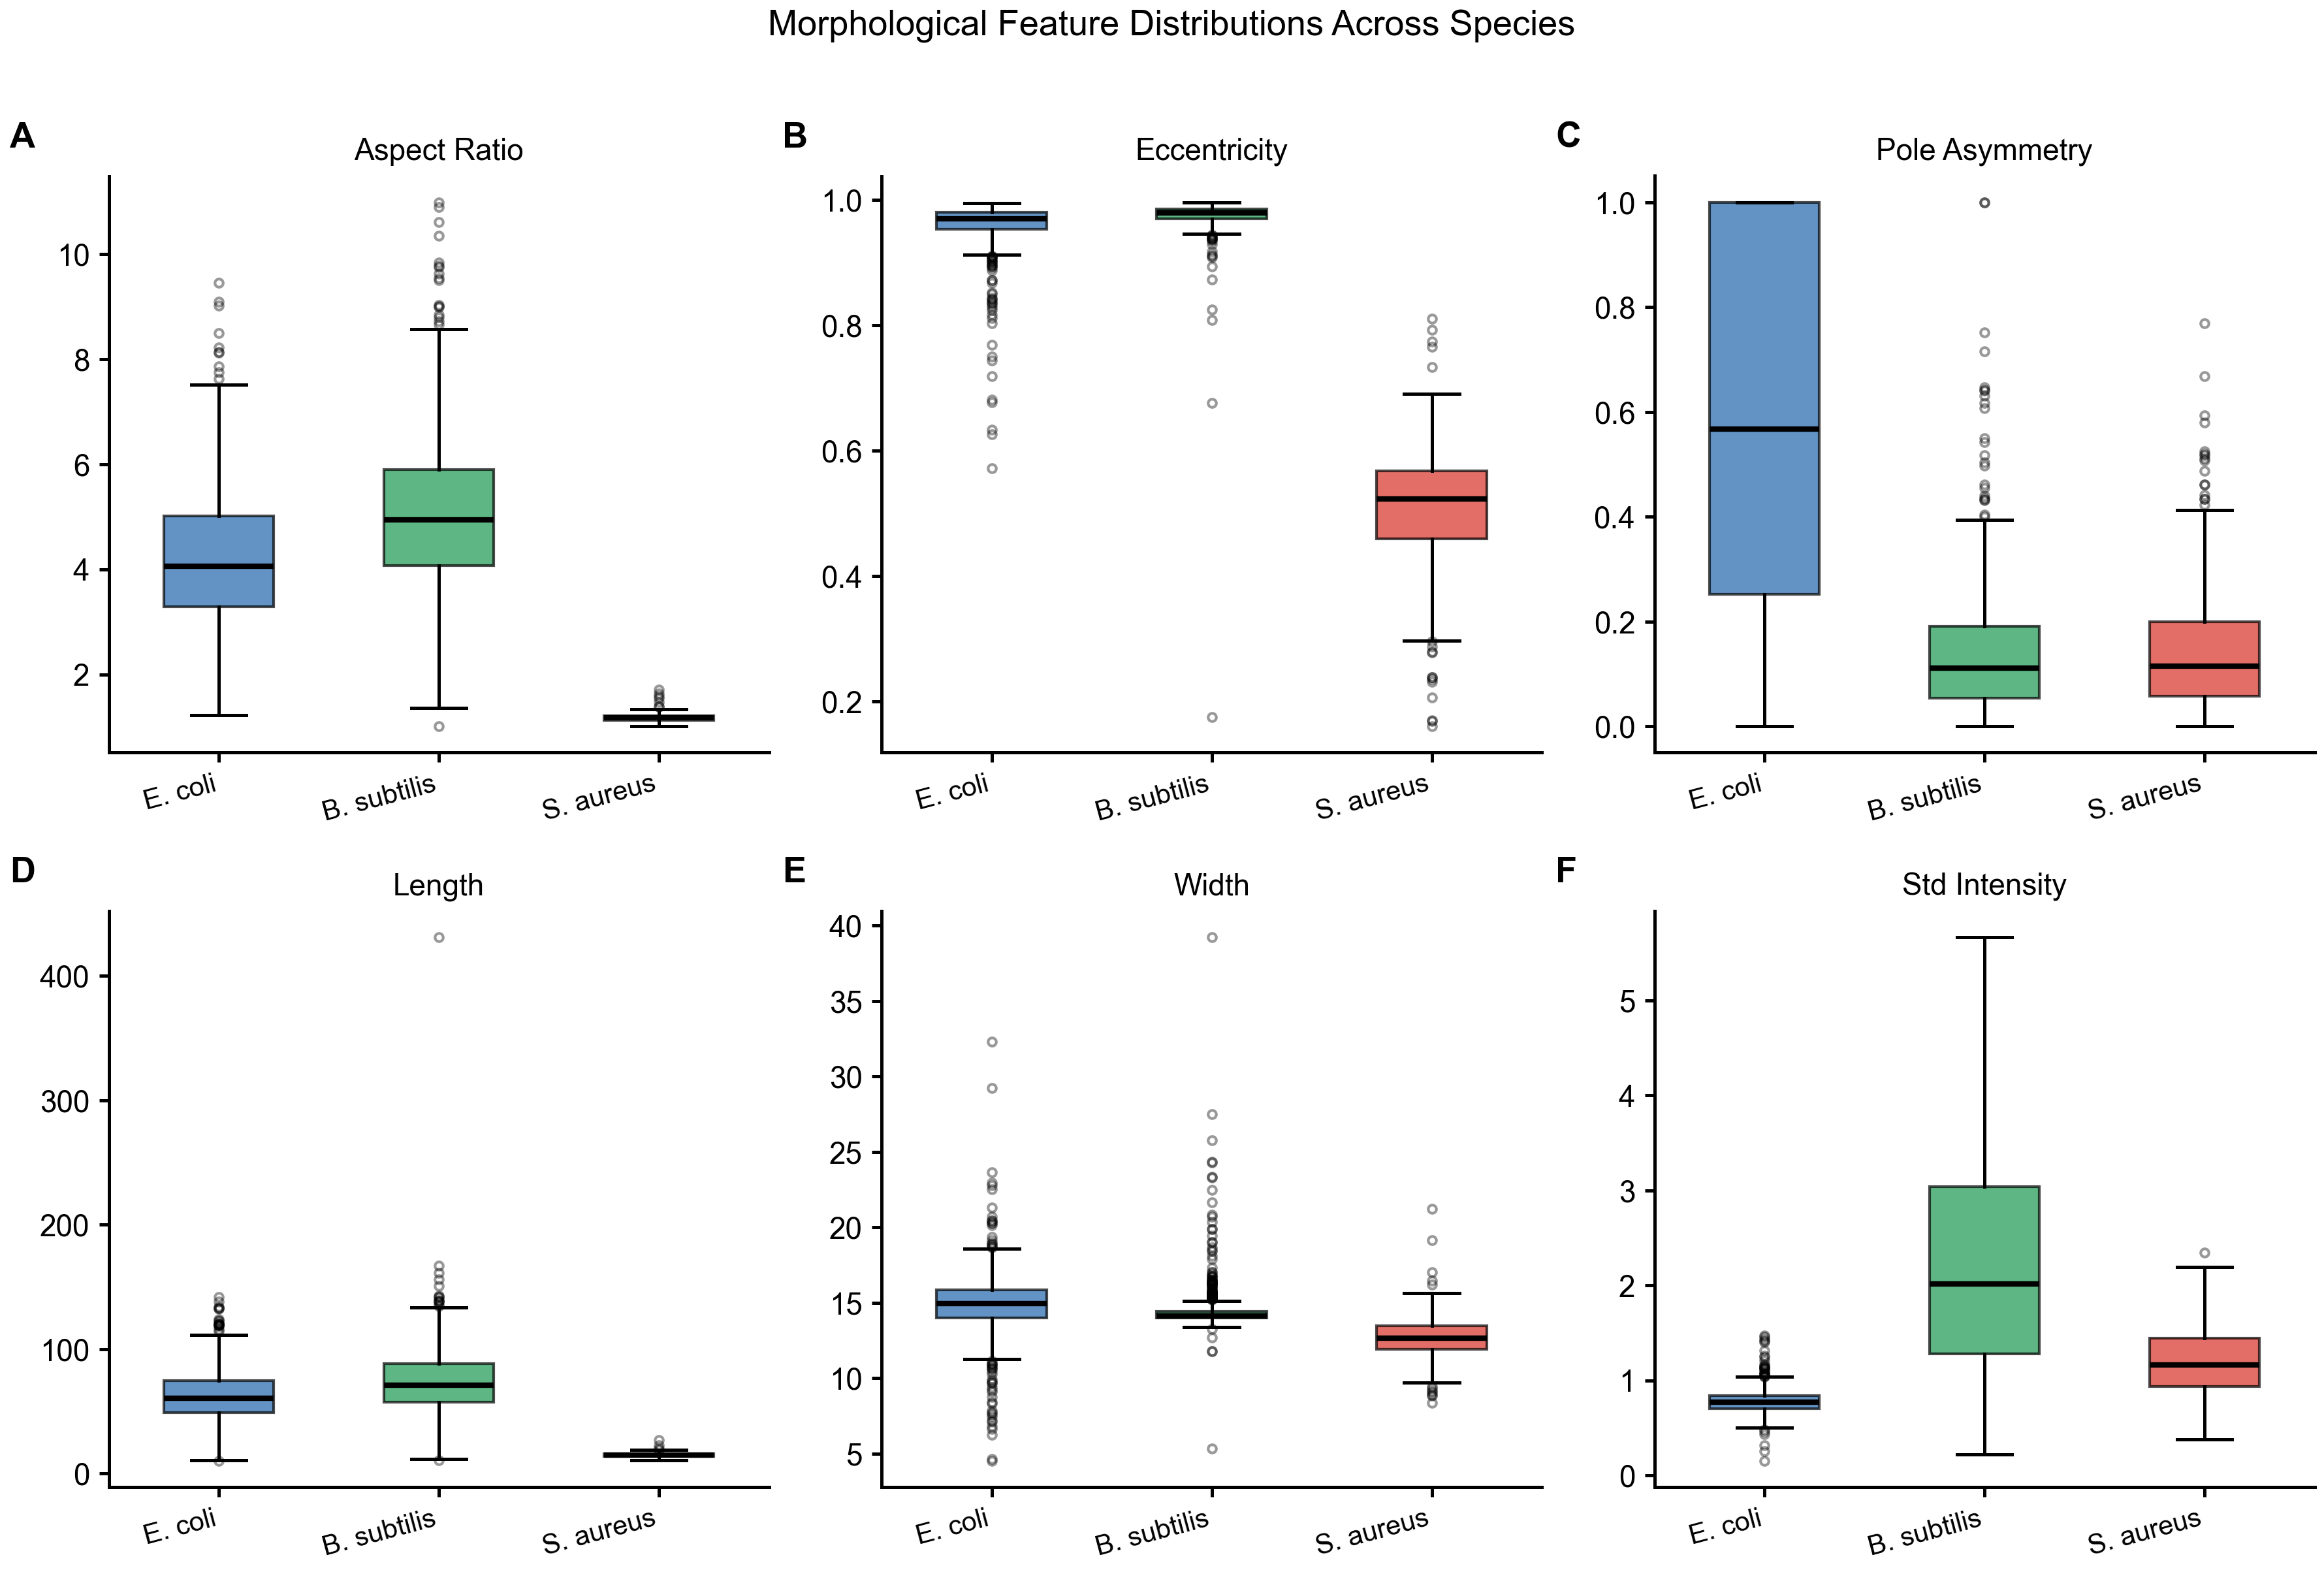

Figure 3 saved.


In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import shap
import joblib
import os

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

BLUE  = '#2166AC'
RED   = '#D73027'
GREY  = '#636363'
GREEN = '#1A9850'

os.makedirs('../outputs/figures', exist_ok=True)

# ── Figure 1: Model Performance ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
aurocs = [0.774, 0.958, 0.974]
mccs   = [0.404, 0.726, 0.780]
colors = [GREY, BLUE, RED]

for ax, values, ylabel, panel in zip(
    axes, [aurocs, mccs],
    ['AUROC (5-fold CV)', 'MCC (5-fold CV)'],
    ['A', 'B']
):
    bars = ax.bar(models, values, color=colors, width=0.5,
                  edgecolor='white', linewidth=0.8)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.text(-0.12, 1.02, panel, transform=ax.transAxes,
            fontsize=14, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/fig1_model_performance.pdf')
plt.savefig('../outputs/figures/fig1_model_performance.png')
plt.show()
print("Figure 1 saved.")

# ── Figure 3: Cross-species boxplot (corrected) ───────────
combined = pd.read_csv('../data/features/deepbacs_features_clean.csv')
features_to_plot = ['aspect_ratio', 'eccentricity', 'pole_asymmetry',
                    'length', 'width', 'std_intensity']
species_order    = ['ecoli', 'bsubtilis', 'staph']
species_labels   = ['E. coli', 'B. subtilis', 'S. aureus']
species_colors   = [BLUE, GREEN, RED]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flat

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    data = [combined[combined['species']==s][feat].dropna().values
            for s in species_order]
    
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3,
                                   alpha=0.4, linestyle='none'))
    for patch, color in zip(bp['boxes'], species_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(species_labels, rotation=15, ha='right', fontsize=10)

# Add panel labels
for i, (ax, letter) in enumerate(zip(axes, 'ABCDEF')):
    ax.text(-0.15, 1.05, letter, transform=ax.transAxes,
            fontsize=13, fontweight='bold')

plt.suptitle('Morphological Feature Distributions Across Species',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/fig3_crossspecies.pdf')
plt.savefig('../outputs/figures/fig3_crossspecies.png')
plt.show()
print("Figure 3 saved.")

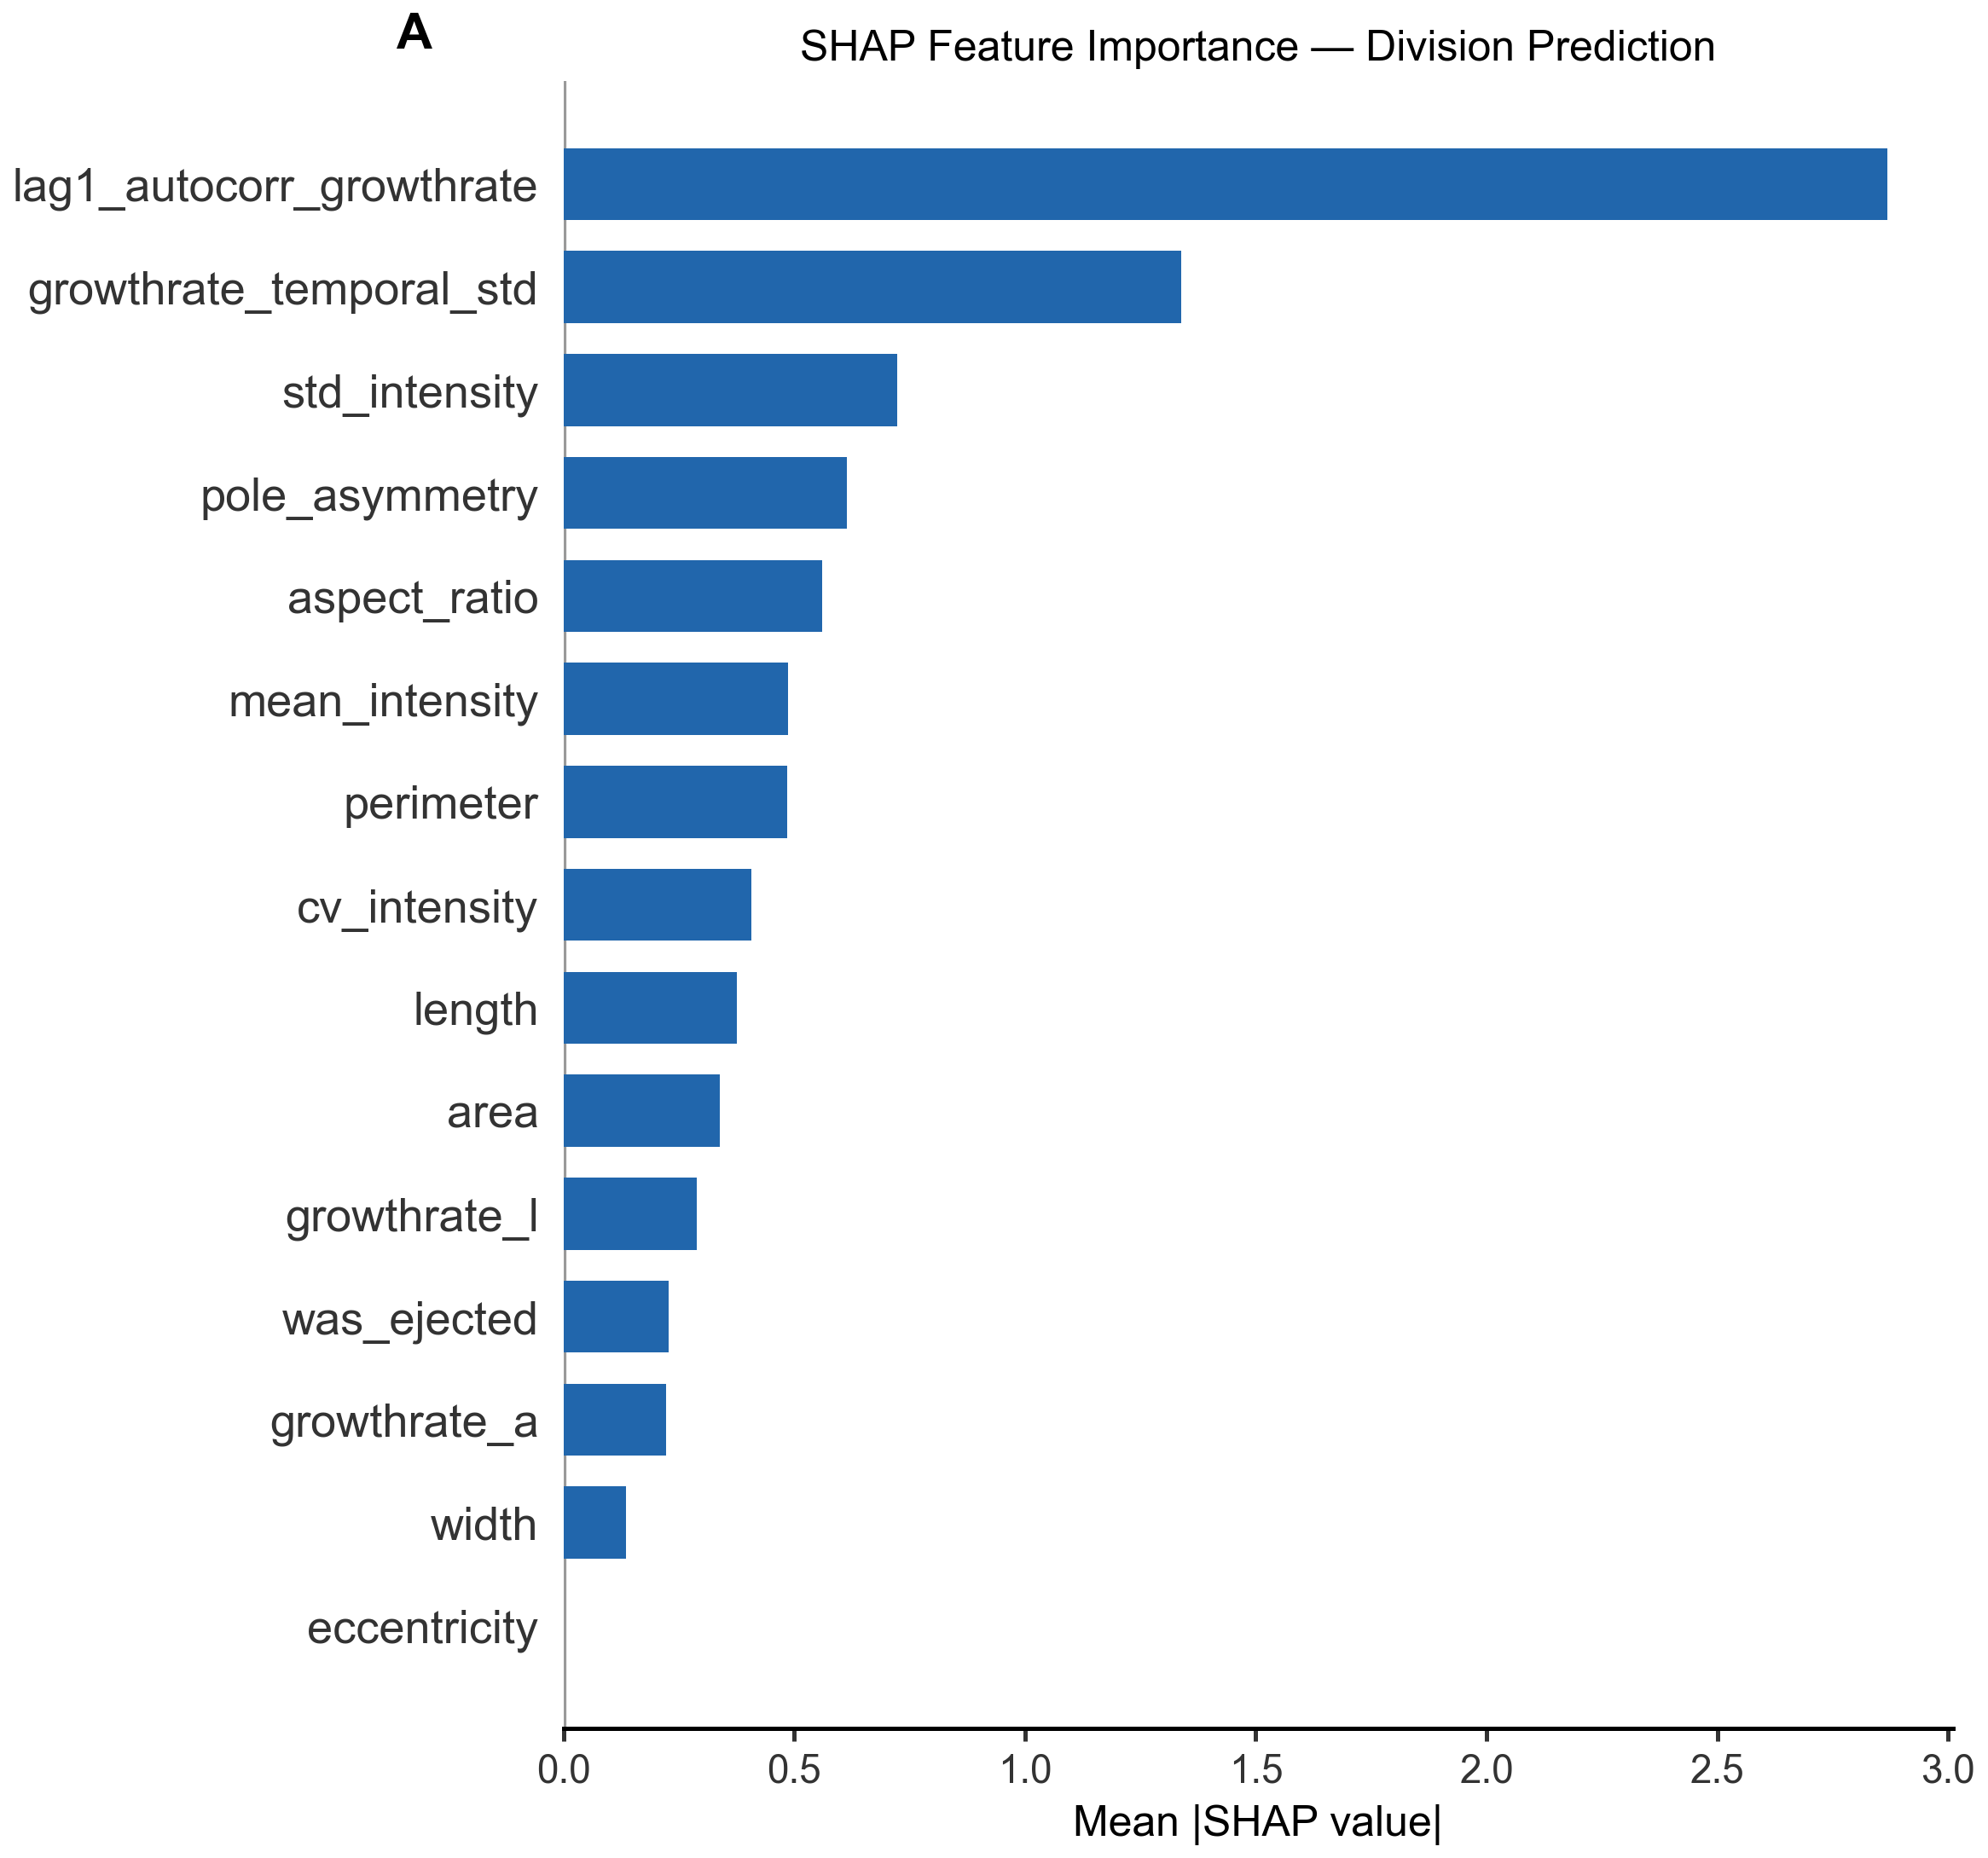

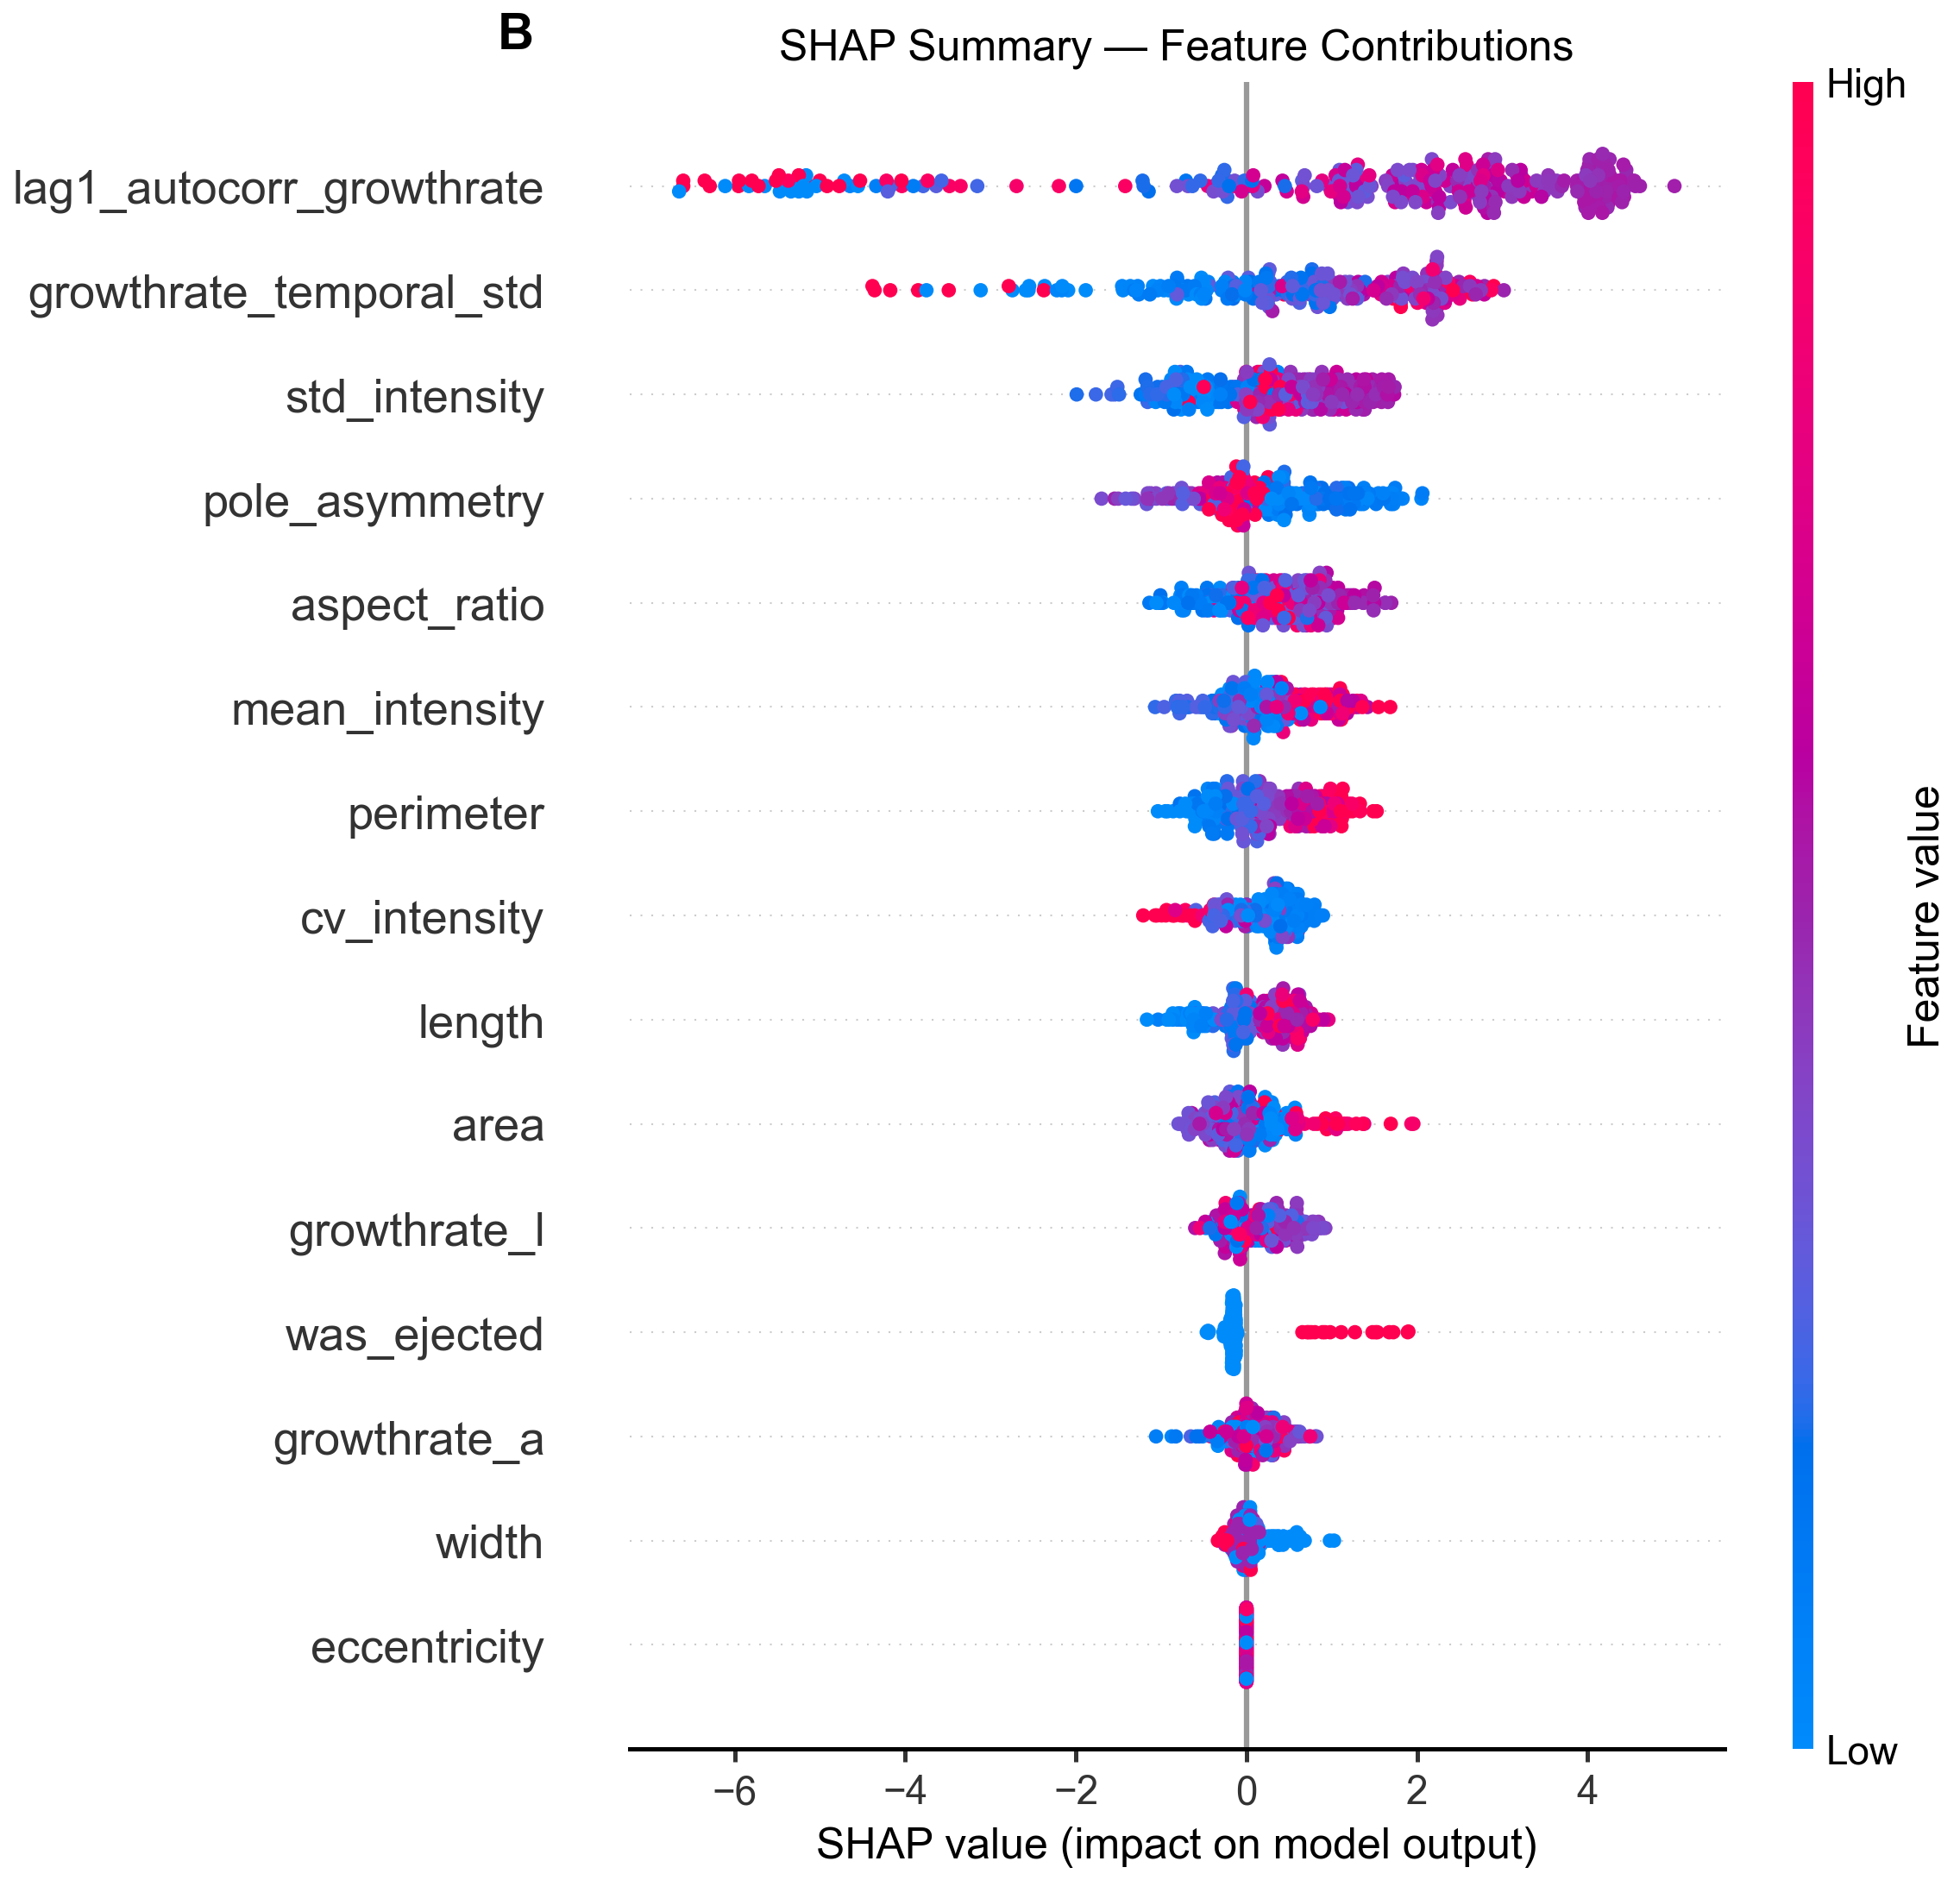

Figure 2 saved.


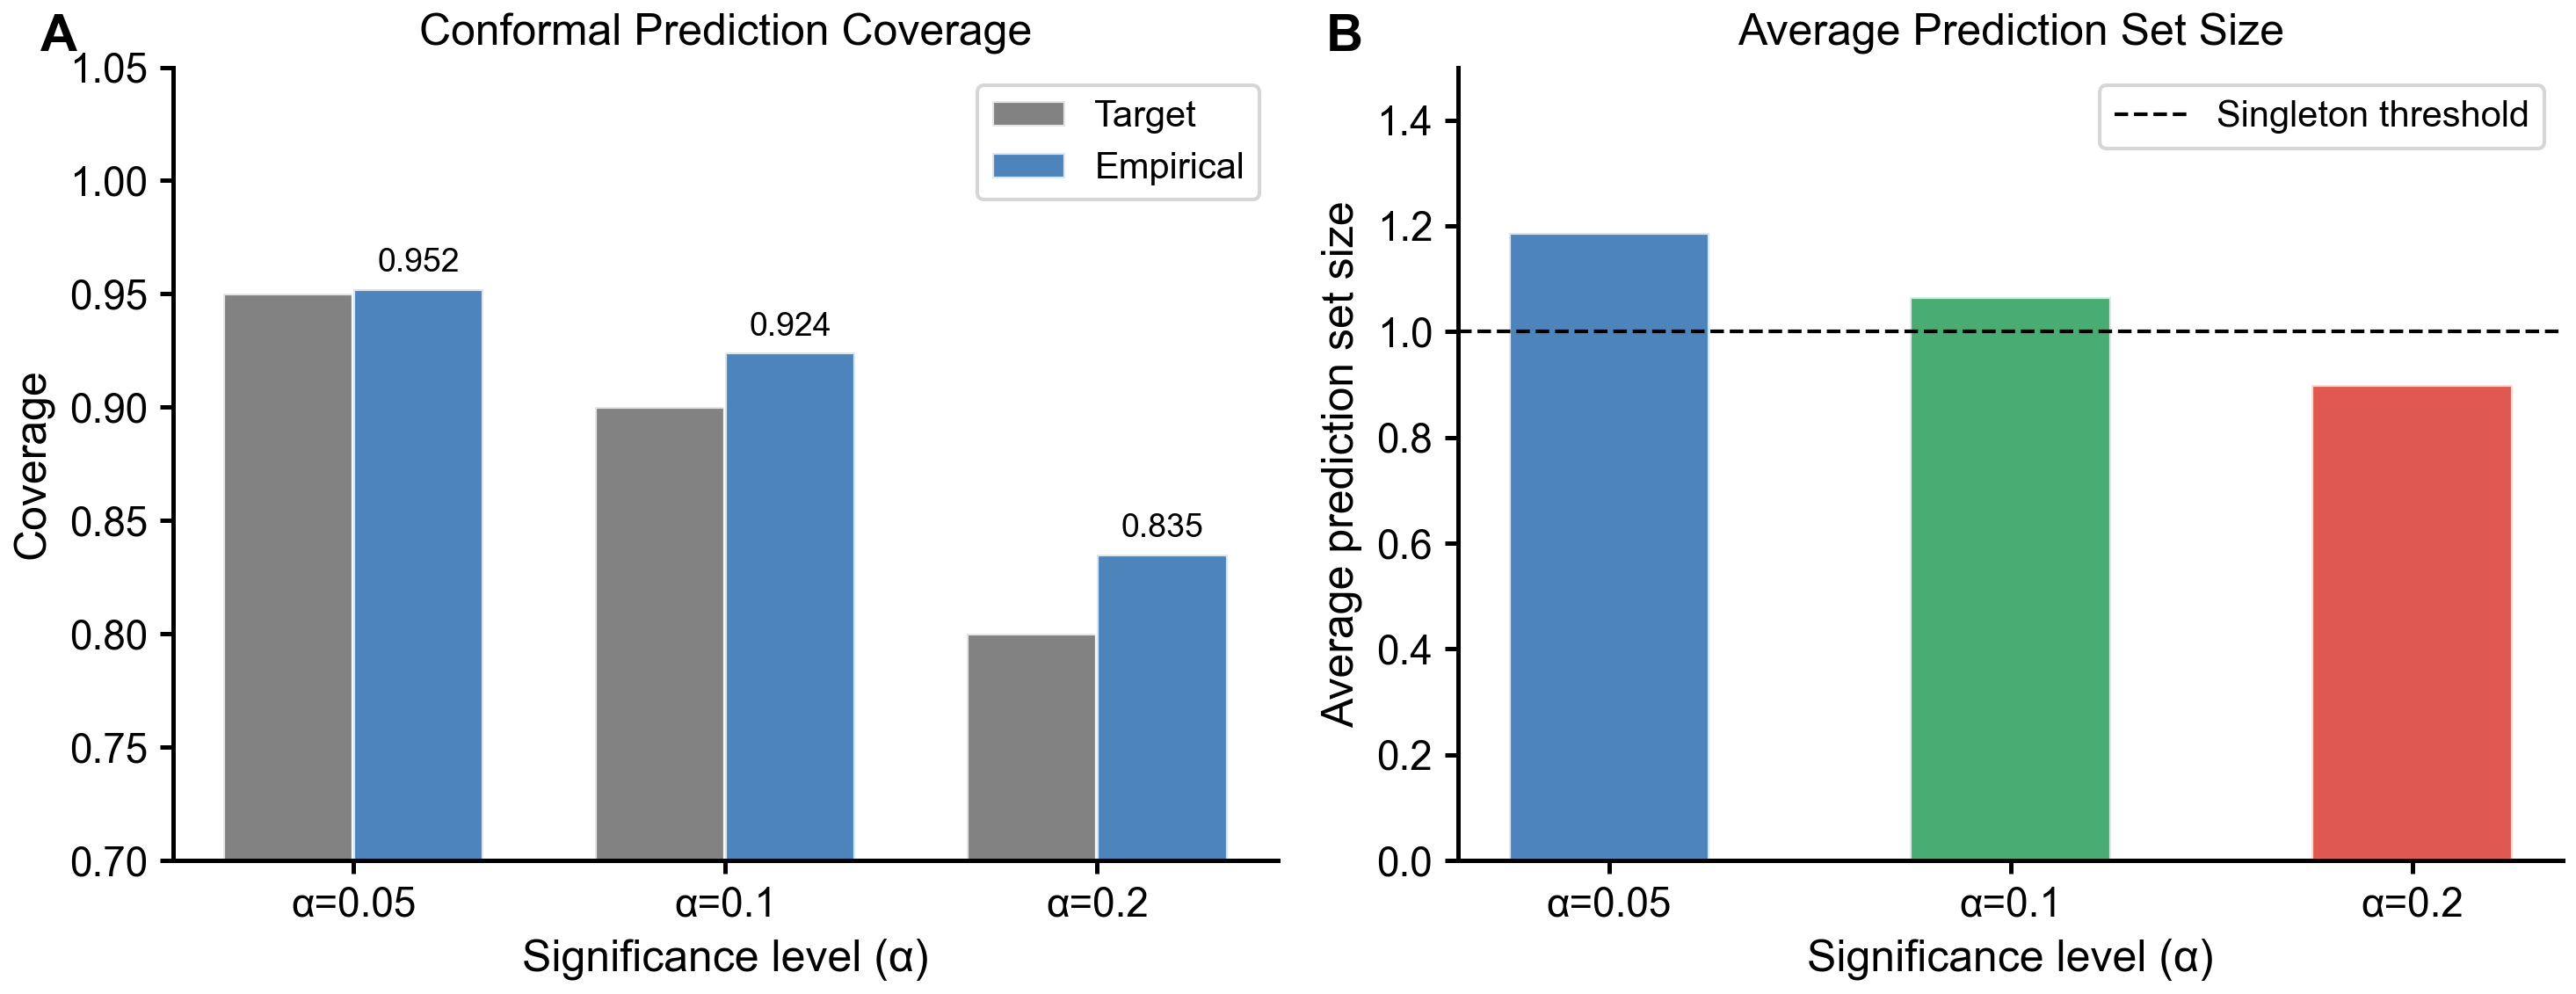

Figure 4 saved.


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/features/feature_matrix_clean.csv')
FEATURE_COLS = [c for c in df.columns if c != 'divided']
X = df[FEATURE_COLS].values
y = df['divided'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Use XGBoost for SHAP (matches Week 4 results)
import xgboost as xgb
clf = xgb.XGBClassifier(n_estimators=200, random_state=42,
                         eval_metric='logloss',
                         scale_pos_weight=(y_train==0).sum()/(y_train==1).sum())
clf.fit(X_train_s, y_train)

explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_s)

# ── Figure 2A: SHAP bar chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_s, feature_names=FEATURE_COLS,
                  plot_type='bar', show=False, color=BLUE)
ax = plt.gca()
ax.set_xlabel('Mean |SHAP value|', fontsize=12)
ax.set_title('SHAP Feature Importance — Division Prediction', fontsize=12)
ax.text(-0.12, 1.02, 'A', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig2a_shap_bar.pdf')
plt.savefig('../outputs/figures/fig2a_shap_bar.png')
plt.show()

# ── Figure 2B: SHAP beeswarm ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_s, feature_names=FEATURE_COLS,
                  show=False)
ax = plt.gca()
ax.set_xlabel('SHAP value (impact on model output)', fontsize=12)
ax.set_title('SHAP Summary — Feature Contributions', fontsize=12)
ax.text(-0.12, 1.02, 'B', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig2b_shap_beeswarm.pdf')
plt.savefig('../outputs/figures/fig2b_shap_beeswarm.png')
plt.show()
print("Figure 2 saved.")

# ── Figure 4: Conformal prediction coverage ──────────────
alpha_levels  = [0.05, 0.10, 0.20]
target_covs   = [0.950, 0.900, 0.800]
empirical_covs= [0.952, 0.924, 0.835]
avg_set_sizes = [1.186, 1.065, 0.900]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x = np.arange(len(alpha_levels))
width = 0.35

ax = axes[0]
bars1 = ax.bar(x - width/2, target_covs,   width, label='Target',
               color=GREY,  alpha=0.8, edgecolor='white')
bars2 = ax.bar(x + width/2, empirical_covs, width, label='Empirical',
               color=BLUE,  alpha=0.8, edgecolor='white')
ax.set_ylabel('Coverage', fontsize=12)
ax.set_xlabel('Significance level (α)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'α={a}' for a in alpha_levels])
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=10)
ax.set_title('Conformal Prediction Coverage', fontsize=12)
ax.text(-0.12, 1.02, 'A', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
for bar, val in zip(bars2, empirical_covs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
ax.bar([f'α={a}' for a in alpha_levels], avg_set_sizes,
       color=[BLUE, GREEN, RED], alpha=0.8, edgecolor='white', width=0.5)
ax.set_ylabel('Average prediction set size', fontsize=12)
ax.set_xlabel('Significance level (α)', fontsize=12)
ax.set_ylim(0, 1.5)
ax.set_title('Average Prediction Set Size', fontsize=12)
ax.text(-0.12, 1.02, 'B', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1,
           label='Singleton threshold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/fig4_conformal.pdf')
plt.savefig('../outputs/figures/fig4_conformal.png')
plt.show()
print("Figure 4 saved.")